In [11]:

# ============================================================
# BƯỚC 1. NẠP DỮ LIỆU VÀ THIẾT LẬP
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from collections import Counter

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.signal import find_peaks

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# ------------------------------------------------------------
# Thiết lập style cho biểu đồ
# ------------------------------------------------------------
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

# ------------------------------------------------------------
# Đường dẫn dữ liệu
# ------------------------------------------------------------
DATA_PATH = r"C:\Users\Admin\Desktop\TANPHAT\hocotruong\Năm ba 2025-2026\HK2_A\Phantichvatrucquandulieu\DA_cuoimon\data_creator_unique.csv"

In [12]:

# ------------------------------------------------------------
# Nạp dữ liệu
# ------------------------------------------------------------
df = pd.read_csv(DATA_PATH)

print("=" * 80)
print("THÔNG TIN DỮ LIỆU")
print("=" * 80)
print(f"Shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())
print("\nHead:")
print(df.head())

# ------------------------------------------------------------
# Dữ liệu clustering: toàn bộ cột số
# ------------------------------------------------------------
X = df.select_dtypes(include=[np.number]).copy()

print("\n" + "=" * 80)
print("MA TRẬN ĐẦU VÀO CHO CLUSTERING")
print("=" * 80)
print(f"Số samples  : {X.shape[0]}")
print(f"Số features : {X.shape[1]}")


THÔNG TIN DỮ LIỆU
Shape: (2850, 27)

Columns:
['CREATOR_ID', 'FOLLOWERS', 'FOLLOWING_COUNT', 'ENGAGEMENT', 'TOTAL_LIKES', 'DIGG_COUNT', 'VIDEO_COUNT', 'COLLAB_SCORE', 'HAS_BROADCAST_SCORE', 'PRICE_NUM', 'grp_ENTERTAINMENT', 'grp_LIFESTYLE', 'grp_FOOD', 'grp_BEAUTY', 'grp_FASHION', 'grp_GAMING', 'grp_TECH', 'grp_COMMERCE', 'grp_EDUCATION', 'grp_NEWS', 'grp_PETS_NATURE', 'grp_SPORTS', 'grp_TRAVEL', 'grp_FAMILY_KIDS', 'grp_HOME_DIY', 'grp_UNKNOWN', 'CATEGORY_GROUP_COUNT']

Head:
    CREATOR_ID  FOLLOWERS  FOLLOWING_COUNT  ENGAGEMENT  TOTAL_LIKES  \
0     endersff  12.978495         4.574711        0.88    15.919645   
1   aigonew1ld  11.112463         2.197225       11.12    14.603968   
2  khucanhhung  12.002125         4.007333        5.11    15.573369   
3  hieuride17x  11.297266         5.365976       13.80    14.845130   
4     wonrtoys  12.900222         4.174387        2.17    15.009433   

   DIGG_COUNT  VIDEO_COUNT  COLLAB_SCORE  HAS_BROADCAST_SCORE  PRICE_NUM  ...  \
0    9.0992

In [ ]:
df.duplicated().sum()

0

In [16]:
df.drop(columns=['CREATOR_ID'], inplace=True)

In [17]:
print(df.shape)
print(df.columns.tolist())
df.describe(percentiles=[0.5, 0.9, 0.99]).T

(2850, 26)
['FOLLOWERS', 'FOLLOWING_COUNT', 'ENGAGEMENT', 'TOTAL_LIKES', 'DIGG_COUNT', 'VIDEO_COUNT', 'COLLAB_SCORE', 'HAS_BROADCAST_SCORE', 'PRICE_NUM', 'grp_ENTERTAINMENT', 'grp_LIFESTYLE', 'grp_FOOD', 'grp_BEAUTY', 'grp_FASHION', 'grp_GAMING', 'grp_TECH', 'grp_COMMERCE', 'grp_EDUCATION', 'grp_NEWS', 'grp_PETS_NATURE', 'grp_SPORTS', 'grp_TRAVEL', 'grp_FAMILY_KIDS', 'grp_HOME_DIY', 'grp_UNKNOWN', 'CATEGORY_GROUP_COUNT']


,count,mean,std,min,50%,90%,99%,max
FOLLOWERS,2850.0,11.882637,1.602313,0.000000,11.912044,13.740270,15.340742,16.869512
FOLLOWING_COUNT,2850.0,4.048940,1.940526,0.000000,4.119004,6.459904,8.800805,9.210440
ENGAGEMENT,2850.0,5.214474,3.959727,0.480000,3.955000,11.013000,19.045700,19.080000
TOTAL_LIKES,2850.0,15.019260,1.531577,7.446001,14.978662,17.014184,18.925732,20.009712
DIGG_COUNT,2850.0,8.320543,1.886376,0.000000,8.461575,10.636836,12.085459,13.225463
VIDEO_COUNT,2850.0,5.843263,1.262728,0.693147,5.928258,7.306598,8.722517,10.488520
COLLAB_SCORE,2850.0,78.412386,5.905490,61.200000,77.200000,87.800000,94.400000,98.800000
HAS_BROADCAST_SCORE,2850.0,0.390877,0.488033,0.000000,0.000000,1.000000,1.000000,1.000000
PRICE_NUM,2850.0,14.435817,1.779652,4.615121,14.508658,16.300417,18.603002,19.337372
grp_ENTERTAINMENT,2850.0,0.472632,0.499338,0.000000,0.000000,1.000000,1.000000,1.000000


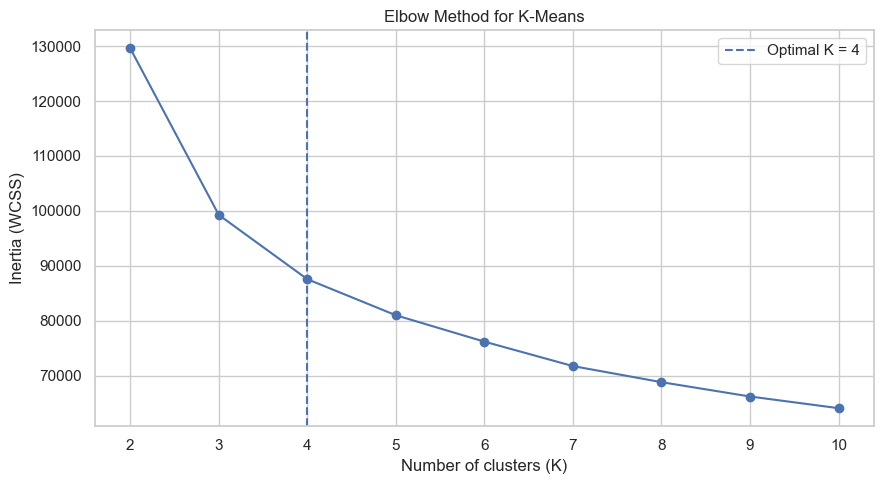


K-Means optimal K: 4
K-Means cluster counts: Counter({1: 1041, 3: 817, 2: 514, 0: 478})


In [18]:

# ============================================================
# BƯỚC 2. TRIỂN KHAI CÁC THUẬT TOÁN PHÂN CỤM
# ============================================================

# ------------------------------------------------------------
# 2.1. K-MEANS: Elbow Method + huấn luyện mô hình
# ------------------------------------------------------------
def find_optimal_k_elbow(X, k_range=range(2, 11), plot=True):
    """
    Tính inertia cho từng K và chọn K tối ưu bằng Elbow Method.
    Ở đây dùng 'distance to line' để xác định điểm khuỷu một cách tự động.

    Parameters
    ----------
    X : array-like
        Ma trận đặc trưng
    k_range : iterable
        Dải giá trị K thử nghiệm
    plot : bool
        Có vẽ biểu đồ Elbow hay không

    Returns
    -------
    optimal_k : int
        Số cụm K tối ưu
    inertias : list
        Danh sách inertia theo từng K
    """
    ks = list(k_range)
    inertias = []

    for k in ks:
        model = KMeans(n_clusters=k, random_state=42, n_init=20)
        model.fit(X)
        inertias.append(model.inertia_)

    # --- tự động tìm elbow bằng khoảng cách từ điểm tới đường nối đầu-cuối ---
    p1 = np.array([ks[0], inertias[0]])
    p2 = np.array([ks[-1], inertias[-1]])

    distances = []
    for k, inertia in zip(ks, inertias):
        p = np.array([k, inertia])
        dist = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)
        distances.append(dist)

    optimal_k = ks[int(np.argmax(distances))]

    if plot:
        plt.figure(figsize=(9, 5))
        plt.plot(ks, inertias, marker="o")
        plt.axvline(optimal_k, linestyle="--", label=f"Optimal K = {optimal_k}")
        plt.title("Elbow Method for K-Means")
        plt.xlabel("Number of clusters (K)")
        plt.ylabel("Inertia (WCSS)")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return optimal_k, inertias


optimal_k_kmeans, inertias = find_optimal_k_elbow(X, k_range=range(2, 11), plot=True)

kmeans = KMeans(n_clusters=optimal_k_kmeans, random_state=42, n_init=20)
kmeans_labels = kmeans.fit_predict(X)

print("\nK-Means optimal K:", optimal_k_kmeans)
print("K-Means cluster counts:", Counter(kmeans_labels))




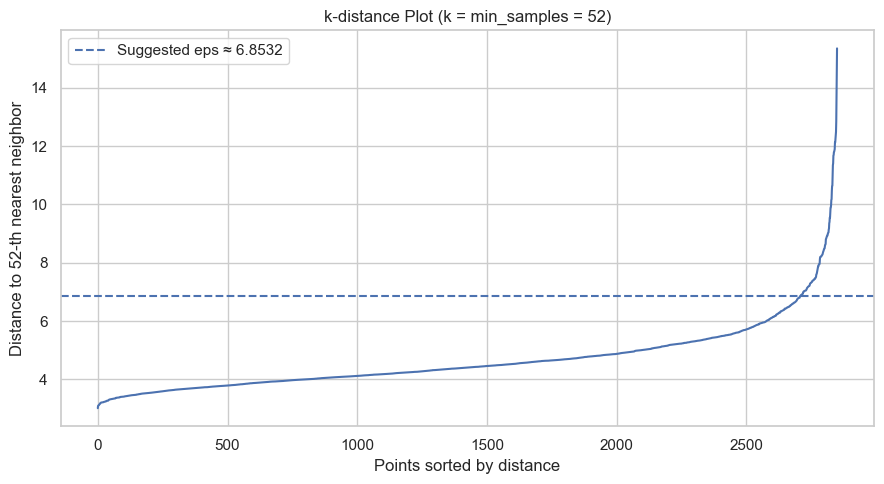


DBSCAN suggested eps       : 6.8532
DBSCAN suggested min_samples: 52
DBSCAN labels counts: Counter({0: 2822, -1: 28})
DBSCAN noise points: 28


In [19]:

# ------------------------------------------------------------
# 2.2. DBSCAN: tìm eps bằng k-distance plot
# ------------------------------------------------------------
def suggest_dbscan_params(X, min_samples=None, percentile=95, plot=True):
    """
    Gợi ý tham số DBSCAN bằng k-distance plot.

    Ý tưởng:
    - Chọn min_samples mặc định = 2 * số chiều, nhưng tối thiểu là 5
    - Tính khoảng cách tới láng giềng thứ k = min_samples
    - Sắp xếp các khoảng cách
    - Gợi ý eps bằng percentile cao (ví dụ 95%)

    Parameters
    ----------
    X : array-like
    min_samples : int or None
    percentile : int
    plot : bool

    Returns
    -------
    eps_suggested : float
    min_samples : int
    k_distances_sorted : np.ndarray
    """
    n_features = X.shape[1]

    if min_samples is None:
        min_samples = max(5, 2 * n_features)

    nn = NearestNeighbors(n_neighbors=min_samples)
    nn.fit(X)

    distances, _ = nn.kneighbors(X)
    # lấy khoảng cách tới láng giềng thứ k
    k_distances = distances[:, -1]
    k_distances_sorted = np.sort(k_distances)

    eps_suggested = np.percentile(k_distances_sorted, percentile)

    if plot:
        plt.figure(figsize=(9, 5))
        plt.plot(k_distances_sorted)
        plt.axhline(eps_suggested, linestyle="--",
                    label=f"Suggested eps ≈ {eps_suggested:.4f}")
        plt.title(f"k-distance Plot (k = min_samples = {min_samples})")
        plt.xlabel("Points sorted by distance")
        plt.ylabel(f"Distance to {min_samples}-th nearest neighbor")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return eps_suggested, min_samples, k_distances_sorted


eps_suggested, min_samples_suggested, kdist = suggest_dbscan_params(
    X,
    min_samples=None,
    percentile=95,
    plot=True
)

dbscan = DBSCAN(eps=eps_suggested, min_samples=min_samples_suggested)
dbscan_labels = dbscan.fit_predict(X)

print("\nDBSCAN suggested eps       :", round(eps_suggested, 4))
print("DBSCAN suggested min_samples:", min_samples_suggested)
print("DBSCAN labels counts:", Counter(dbscan_labels))
print("DBSCAN noise points:", np.sum(dbscan_labels == -1))



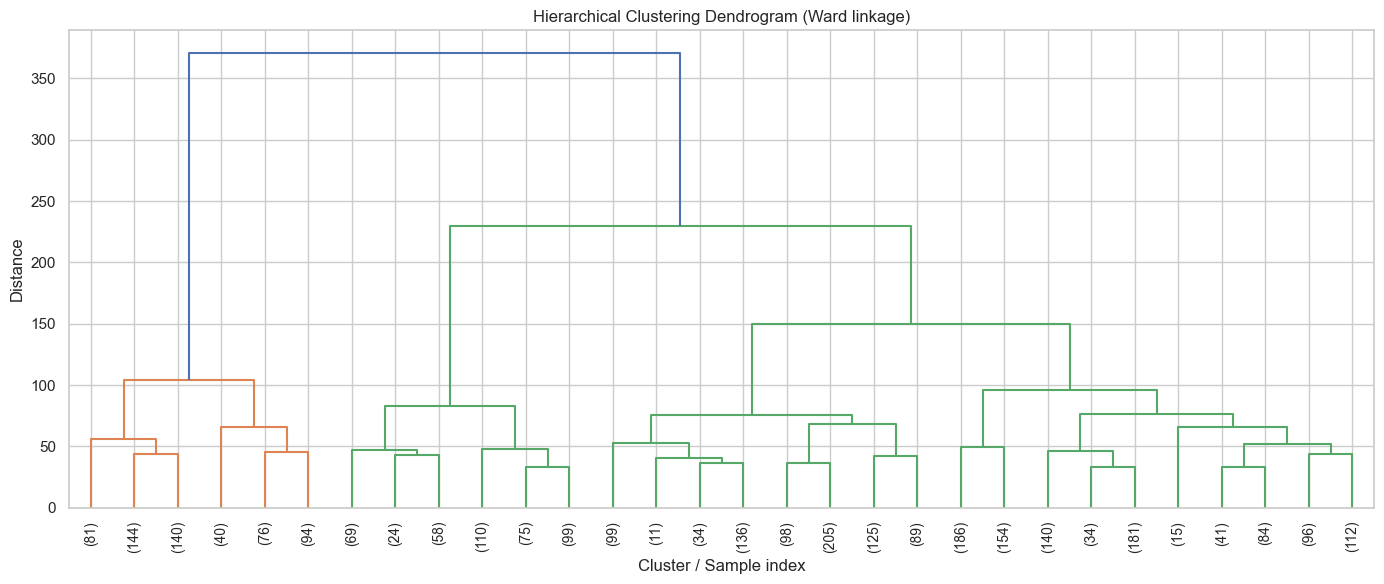


Hierarchical suggested K: 2
Hierarchical cluster counts: Counter({0: 2275, 1: 575})


In [20]:

# ------------------------------------------------------------
# 2.3. HIERARCHICAL CLUSTERING: Dendrogram + huấn luyện
# ------------------------------------------------------------
def plot_dendrogram_and_choose_k(X, truncate_mode="lastp", p=30):
    """
    Vẽ dendrogram để người dùng quan sát trực quan.
    Đồng thời gợi ý số cụm bằng cách xét các khoảng nhảy lớn trong linkage distance.

    Returns
    -------
    Z : linkage matrix
    suggested_k : int
    """
    Z = linkage(X, method="ward")

    plt.figure(figsize=(14, 6))
    dendrogram(Z, truncate_mode=truncate_mode, p=p, leaf_rotation=90, leaf_font_size=10)
    plt.title("Hierarchical Clustering Dendrogram (Ward linkage)")
    plt.xlabel("Cluster / Sample index")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.show()

    # heuristic: tìm khoảng nhảy lớn trong các khoảng cách hợp nhất cuối
    merge_distances = Z[:, 2]
    last_distances = merge_distances[-10:] if len(merge_distances) >= 10 else merge_distances
    diffs = np.diff(last_distances)

    if len(diffs) > 0:
        jump_idx = np.argmax(diffs)
        # số cụm xấp xỉ: số merge cuối còn lại trước cú nhảy
        suggested_k = max(2, len(last_distances) - jump_idx)
    else:
        suggested_k = 3

    return Z, suggested_k


Z, suggested_k_hier = plot_dendrogram_and_choose_k(X, truncate_mode="lastp", p=30)

agglomerative = AgglomerativeClustering(n_clusters=suggested_k_hier, linkage="ward")
hier_labels = agglomerative.fit_predict(X)

print("\nHierarchical suggested K:", suggested_k_hier)
print("Hierarchical cluster counts:", Counter(hier_labels))



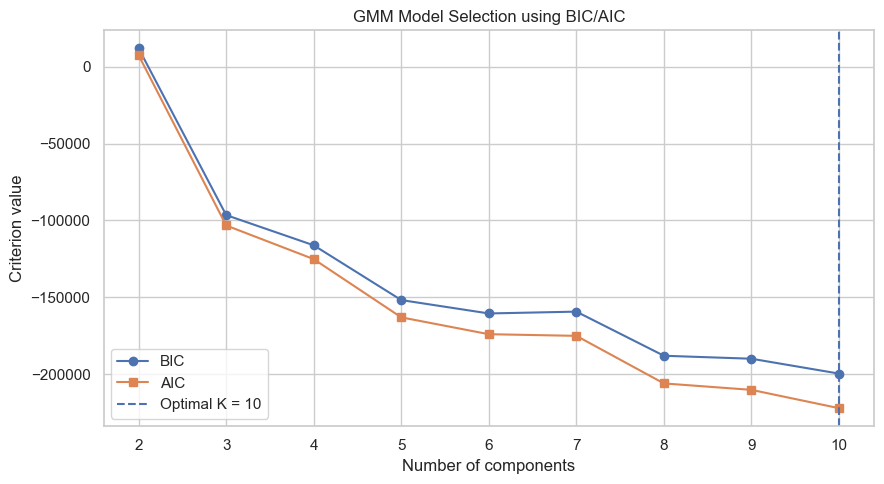


GMM optimal K: 10
GMM cluster counts: Counter({4: 1219, 5: 411, 0: 330, 2: 278, 3: 206, 1: 160, 9: 94, 6: 54, 8: 54, 7: 44})


In [21]:

# ------------------------------------------------------------
# 2.4. GMM: soft clustering
# ------------------------------------------------------------
def find_optimal_k_gmm_bic(X, k_range=range(2, 11), plot=True):
    """
    Chọn số cụm cho GMM bằng BIC: càng thấp càng tốt.
    """
    ks = list(k_range)
    bics = []
    aics = []

    for k in ks:
        gmm = GaussianMixture(n_components=k, random_state=42, covariance_type="full")
        gmm.fit(X)
        bics.append(gmm.bic(X))
        aics.append(gmm.aic(X))

    optimal_k = ks[int(np.argmin(bics))]

    if plot:
        plt.figure(figsize=(9, 5))
        plt.plot(ks, bics, marker="o", label="BIC")
        plt.plot(ks, aics, marker="s", label="AIC")
        plt.axvline(optimal_k, linestyle="--", label=f"Optimal K = {optimal_k}")
        plt.title("GMM Model Selection using BIC/AIC")
        plt.xlabel("Number of components")
        plt.ylabel("Criterion value")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return optimal_k, bics, aics


optimal_k_gmm, bics, aics = find_optimal_k_gmm_bic(X, k_range=range(2, 11), plot=True)

gmm = GaussianMixture(n_components=optimal_k_gmm, random_state=42, covariance_type="full")
gmm_labels = gmm.fit_predict(X)
gmm_probs = gmm.predict_proba(X)

print("\nGMM optimal K:", optimal_k_gmm)
print("GMM cluster counts:", Counter(gmm_labels))


In [22]:

# ============================================================
# BƯỚC 3. ĐÁNH GIÁ MÔ HÌNH
# ============================================================

def evaluate_clustering(X, labels, model_name):
    """
    Tính 3 chỉ số đánh giá cụm:
    - Silhouette Score: càng cao càng tốt
    - Davies-Bouldin Index: càng thấp càng tốt
    - Calinski-Harabasz Index: càng cao càng tốt

    Lưu ý:
    - DBSCAN có thể tạo noise label = -1
    - Nếu tất cả điểm thuộc cùng một cụm, metrics không còn ý nghĩa
    """
    unique_labels = set(labels)

    # Số cụm thực, không tính noise (-1)
    n_clusters = len(unique_labels - {-1})
    n_noise = np.sum(np.array(labels) == -1)

    # Nếu cụm hợp lệ < 2 thì không tính được metrics
    if n_clusters < 2:
        return {
            "Algorithm": model_name,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "Silhouette": np.nan,
            "Davies_Bouldin": np.nan,
            "Calinski_Harabasz": np.nan
        }

    # Với DBSCAN, để đánh giá "chất lượng cụm lõi", thường loại noise khỏi metric
    if -1 in unique_labels:
        mask = np.array(labels) != -1
        X_eval = X[mask]
        labels_eval = np.array(labels)[mask]
    else:
        X_eval = X
        labels_eval = labels

    # Nếu sau khi bỏ noise mà vẫn < 2 cụm thì trả NaN
    if len(set(labels_eval)) < 2:
        return {
            "Algorithm": model_name,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "Silhouette": np.nan,
            "Davies_Bouldin": np.nan,
            "Calinski_Harabasz": np.nan
        }

    sil = silhouette_score(X_eval, labels_eval)
    dbi = davies_bouldin_score(X_eval, labels_eval)
    chi = calinski_harabasz_score(X_eval, labels_eval)

    return {
        "Algorithm": model_name,
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "Silhouette": sil,
        "Davies_Bouldin": dbi,
        "Calinski_Harabasz": chi
    }


results = []
results.append(evaluate_clustering(X.values, kmeans_labels, "K-Means"))
results.append(evaluate_clustering(X.values, dbscan_labels, "DBSCAN"))
results.append(evaluate_clustering(X.values, hier_labels, "Hierarchical (Ward)"))
results.append(evaluate_clustering(X.values, gmm_labels, "GMM"))

results_df = pd.DataFrame(results)

print("\n" + "=" * 80)
print("BẢNG SO SÁNH KẾT QUẢ")
print("=" * 80)
print(results_df)



BẢNG SO SÁNH KẾT QUẢ
             Algorithm  n_clusters  n_noise  Silhouette  Davies_Bouldin  \
0              K-Means           4        0    0.214367        1.486314   
1               DBSCAN           1       28         NaN             NaN   
2  Hierarchical (Ward)           2        0    0.373869        1.006515   
3                  GMM          10        0   -0.116878        7.226257   

   Calinski_Harabasz  
0        1221.817881  
1                NaN  
2        1485.632491  
3          29.016252  



Explained variance ratio by PCA: [0.50207443 0.23210059]


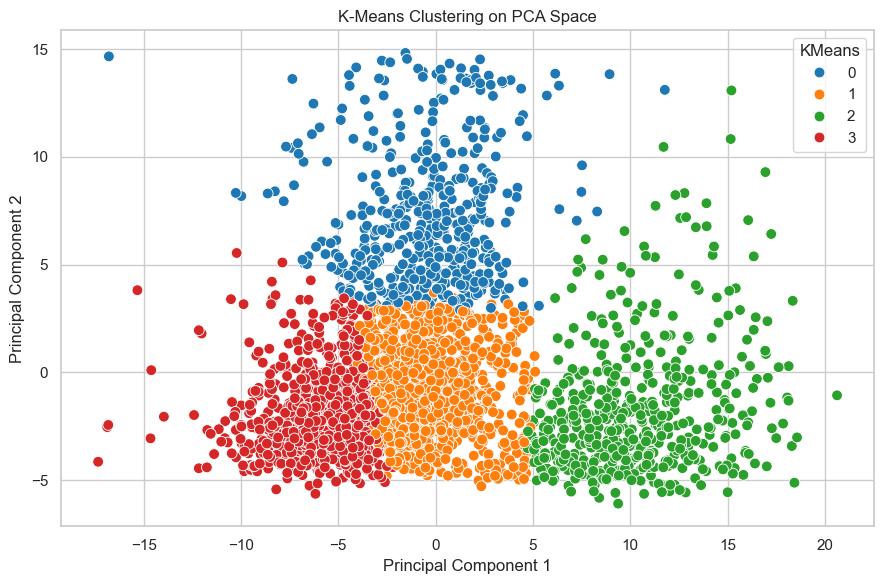

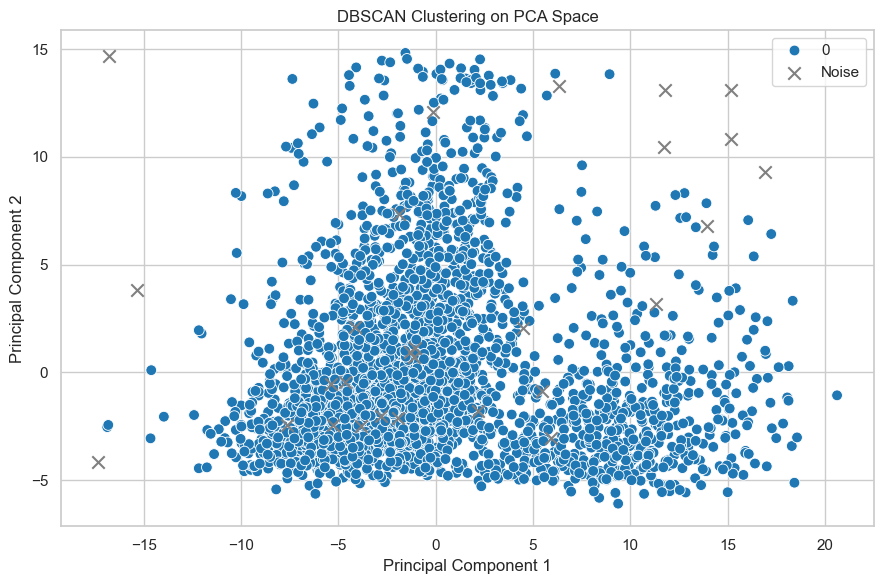

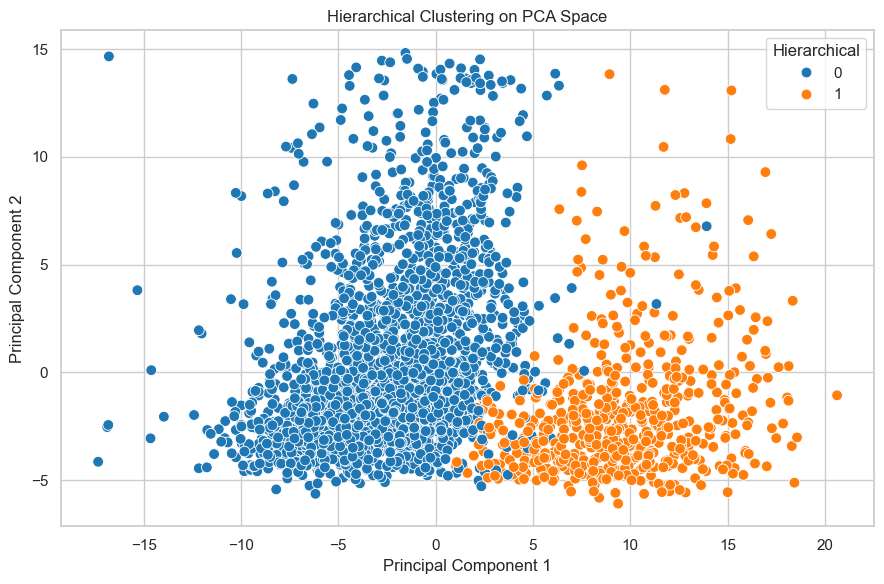

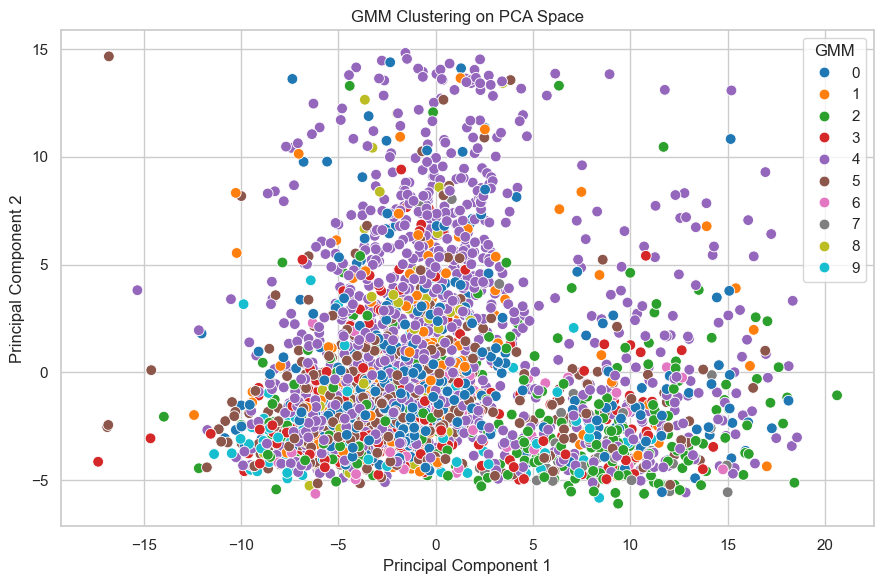

In [23]:

# ============================================================
# BƯỚC 4. TRỰC QUAN HÓA KẾT QUẢ
# ============================================================

# ------------------------------------------------------------
# 4.1. PCA cho trực quan hóa cụm
# ------------------------------------------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "KMeans": kmeans_labels,
    "DBSCAN": dbscan_labels,
    "Hierarchical": hier_labels,
    "GMM": gmm_labels
})

print("\nExplained variance ratio by PCA:", pca.explained_variance_ratio_)


def plot_cluster_scatter(pca_df, label_col, title, is_dbscan=False):
    """
    Vẽ scatter plot 2D theo PCA cho từng thuật toán.

    Riêng DBSCAN:
    - noise (-1) được làm nổi bật bằng màu xám và marker X
    """
    plt.figure(figsize=(9, 6))

    if is_dbscan:
        clustered = pca_df[pca_df[label_col] != -1]
        noise = pca_df[pca_df[label_col] == -1]

        if len(clustered) > 0:
            sns.scatterplot(
                data=clustered, x="PC1", y="PC2",
                hue=label_col, palette="tab10", s=60
            )

        if len(noise) > 0:
            plt.scatter(
                noise["PC1"], noise["PC2"],
                c="gray", marker="x", s=80, label="Noise"
            )
        plt.legend()
    else:
        sns.scatterplot(
            data=pca_df, x="PC1", y="PC2",
            hue=label_col, palette="tab10", s=60
        )

    plt.title(title)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.tight_layout()
    plt.show()


plot_cluster_scatter(pca_df, "KMeans", "K-Means Clustering on PCA Space")
plot_cluster_scatter(pca_df, "DBSCAN", "DBSCAN Clustering on PCA Space", is_dbscan=True)
plot_cluster_scatter(pca_df, "Hierarchical", "Hierarchical Clustering on PCA Space")
plot_cluster_scatter(pca_df, "GMM", "GMM Clustering on PCA Space")



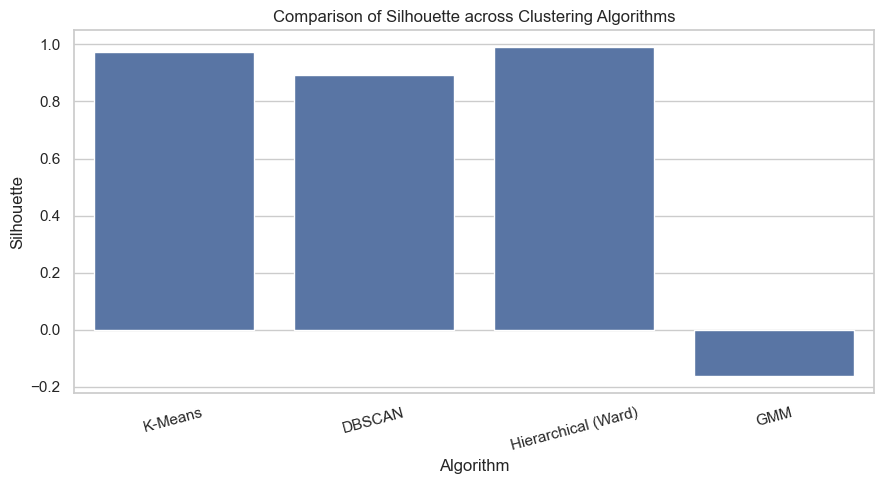

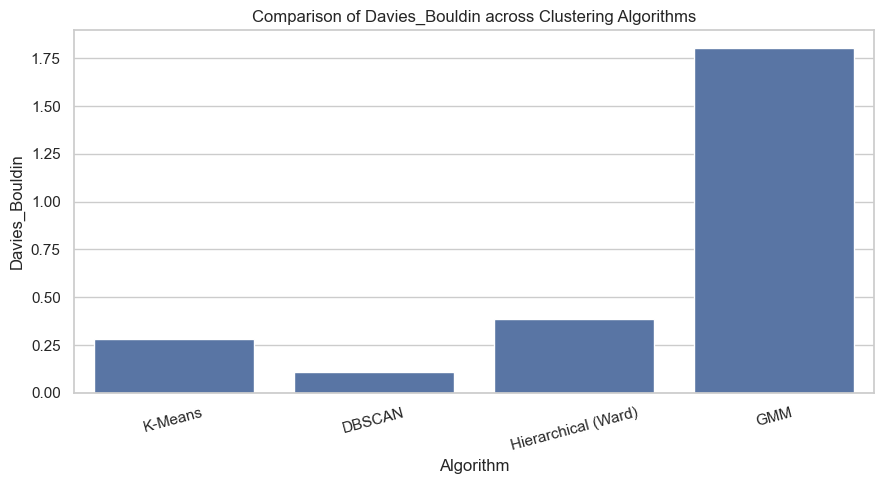

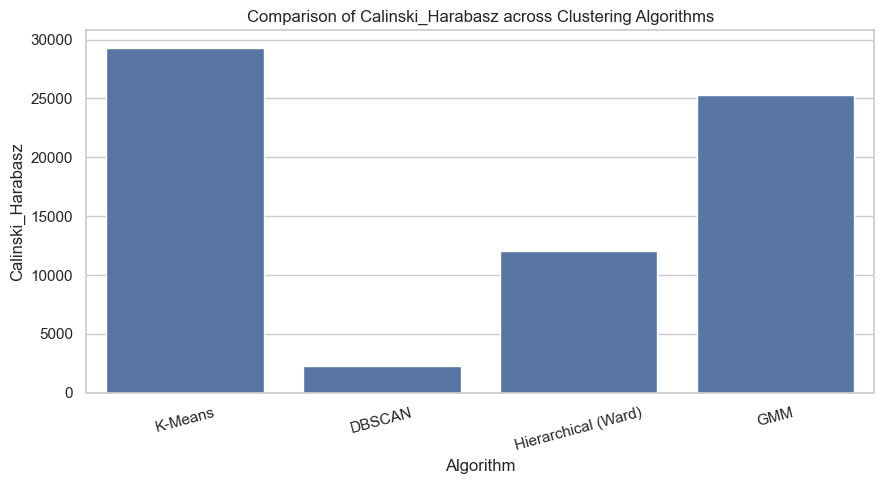

In [33]:

# ------------------------------------------------------------
# 4.2. Biểu đồ cột so sánh các metric
# ------------------------------------------------------------
metrics_to_plot = ["Silhouette", "Davies_Bouldin", "Calinski_Harabasz"]

for metric in metrics_to_plot:
    plt.figure(figsize=(9, 5))
    sns.barplot(data=results_df, x="Algorithm", y=metric)
    plt.title(f"Comparison of {metric} across Clustering Algorithms")
    plt.xlabel("Algorithm")
    plt.ylabel(metric)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()



In [25]:

# ============================================================
# PHẦN KẾT LUẬN NHANH
# ============================================================

print("\n" + "=" * 80)
print("KẾT LUẬN GỢI Ý")
print("=" * 80)

# Thuật toán tốt nhất theo từng chỉ số
best_sil = results_df.loc[results_df["Silhouette"].idxmax(), "Algorithm"] if results_df["Silhouette"].notna().any() else None
best_dbi = results_df.loc[results_df["Davies_Bouldin"].idxmin(), "Algorithm"] if results_df["Davies_Bouldin"].notna().any() else None
best_chi = results_df.loc[results_df["Calinski_Harabasz"].idxmax(), "Algorithm"] if results_df["Calinski_Harabasz"].notna().any() else None

print(f"Best by Silhouette Score       : {best_sil}")
print(f"Best by Davies-Bouldin Index   : {best_dbi}")
print(f"Best by Calinski-Harabasz Index: {best_chi}")

print("\nBảng kết quả cuối:")
print(results_df.sort_values(by="Silhouette", ascending=False))

# ------------------------------------------------------------
# Lưu kết quả nếu cần
# ------------------------------------------------------------
# results_df.to_csv("clustering_comparison_results.csv", index=False)
# pca_df.to_csv("clustering_pca_labels.csv", index=False)

print("\nĐã lưu:")
print("- clustering_comparison_results.csv")
print("- clustering_pca_labels.csv")


KẾT LUẬN GỢI Ý
Best by Silhouette Score       : Hierarchical (Ward)
Best by Davies-Bouldin Index   : Hierarchical (Ward)
Best by Calinski-Harabasz Index: Hierarchical (Ward)

Bảng kết quả cuối:
             Algorithm  n_clusters  n_noise  Silhouette  Davies_Bouldin  \
2  Hierarchical (Ward)           2        0    0.373869        1.006515   
0              K-Means           4        0    0.214367        1.486314   
3                  GMM          10        0   -0.116878        7.226257   
1               DBSCAN           1       28         NaN             NaN   

   Calinski_Harabasz  
2        1485.632491  
0        1221.817881  
3          29.016252  
1                NaN  

Đã lưu:
- clustering_comparison_results.csv
- clustering_pca_labels.csv
